<h1 style="text-align:center; color:#2E4057;">📧 AdaBoost ile Spam E-posta Sınıflandırması</h1>
<h3 style="text-align:center; color:#555;">Spambase Dataset (UCI)</h3>

Bu defterde **AdaBoost (Adaptive Boosting)** algoritmasını, klasik bir zayıf öğrenici birleştirme problemi olan **Spambase** veri seti üzerinde uygulayacağız. Amaç, bir e-postanın kelime/karakter frekanslarına bakarak **spam mi normal mi (ham)** olduğunu sınıflandırmaktır.

## 📋 Veri Seti Değişken Sözlüğü

| Değişken | Açıklama | Tür |
|---|---|---|
| `word_freq_*` (48 sütun) | İlgili kelimenin e-postadaki yüzdesel frekansı | Sayısal |
| `char_freq_*` (6 sütun) | İlgili karakterin (`;`, `(`, `[`, `!`, `$`, `#`) yüzdesel frekansı | Sayısal |
| `capital_run_length_average` | Ardışık büyük harf dizilerinin ortalama uzunluğu | Sayısal |
| `capital_run_length_longest` | En uzun ardışık büyük harf dizisi | Sayısal |
| `capital_run_length_total` | Toplam büyük harf sayısı | Sayısal |
| `is_spam` | Hedef değişken (1=spam, 0=normal e-posta) | Kategorik (0/1) |

## 1️⃣ Kütüphanelerin İçe Aktarılması

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, RocCurveDisplay)

sns.set_style('whitegrid')
RANDOM_STATE = 42

## 2️⃣ Veri Setinin Yüklenmesi ve Keşfi

In [2]:
with open('spambase/spambase.names') as f:
    lines = [l for l in f if ':' in l and not l.startswith('|')]
col_names = [l.split(':')[0].strip() for l in lines] + ['is_spam']

df = pd.read_csv('spambase/spambase.data', header=None, names=col_names)
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,is_spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [3]:
print(f"📐 Boyut : {df.shape[0]:,} satır × {df.shape[1]} sütun")

📐 Boyut : 4,601 satır × 58 sütun


In [4]:
print("❓ Eksik Değer Analizi:")
print(df.isnull().sum().sum())

❓ Eksik Değer Analizi:
0


In [5]:
print("📊 İstatistiksel Özet:")
df.describe().T.head(10)

📊 İstatistiksel Özet:


,count,mean,std,min,25%,50%,75%,max
word_freq_make,4601.0,0.104553,0.305358,0.0,0.0,0.0,0.00,4.54
word_freq_address,4601.0,0.213015,1.290575,0.0,0.0,0.0,0.00,14.28
word_freq_all,4601.0,0.280656,0.504143,0.0,0.0,0.0,0.42,5.10
word_freq_3d,4601.0,0.065425,1.395151,0.0,0.0,0.0,0.00,42.81
word_freq_our,4601.0,0.312223,0.672513,0.0,0.0,0.0,0.38,10.00
word_freq_over,4601.0,0.095901,0.273824,0.0,0.0,0.0,0.00,5.88
word_freq_remove,4601.0,0.114208,0.391441,0.0,0.0,0.0,0.00,7.27
word_freq_internet,4601.0,0.105295,0.401071,0.0,0.0,0.0,0.00,11.11
word_freq_order,4601.0,0.090067,0.278616,0.0,0.0,0.0,0.00,5.26
word_freq_mail,4601.0,0.239413,0.644755,0.0,0.0,0.0,0.16,18.18


In [6]:
print("🏷️  Hedef Değişken (is_spam) Dağılımı:")
print(df['is_spam'].value_counts())
print(df['is_spam'].value_counts(normalize=True).round(3))

🏷️  Hedef Değişken (is_spam) Dağılımı:
is_spam
0    2788
1    1813
Name: count, dtype: int64
is_spam
0    0.606
1    0.394
Name: proportion, dtype: float64


## 3️⃣ Görsel Keşifsel Veri Analizi (EDA)

/tmp/ipykernel_643/2739976677.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_spam', y='char_freq_!', data=df, ax=axes[1], palette=['#2E4057', '#D64550'])


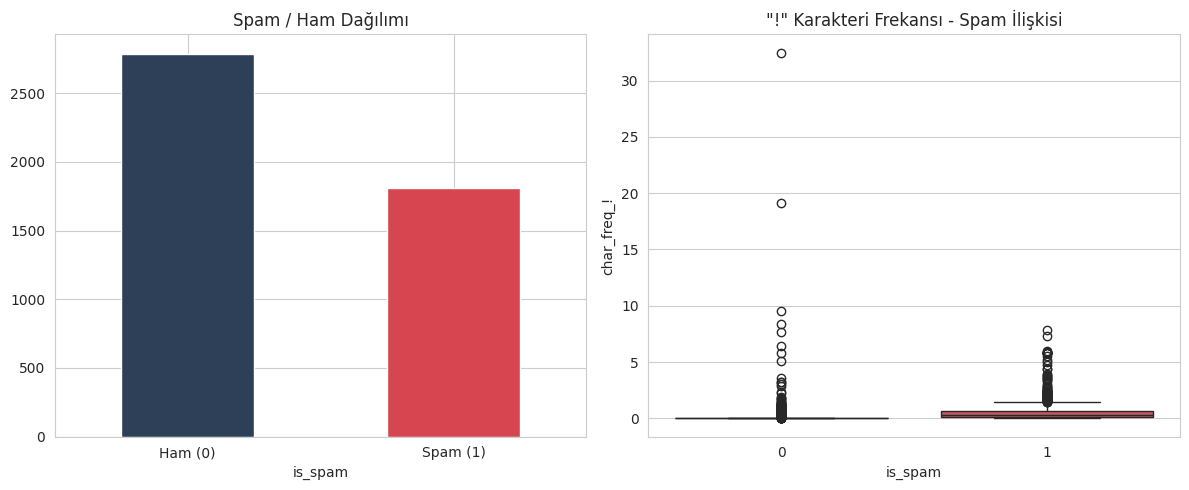

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df['is_spam'].value_counts().plot(kind='bar', ax=axes[0], color=['#2E4057', '#D64550'])
axes[0].set_title('Spam / Ham Dağılımı')
axes[0].set_xticklabels(['Ham (0)', 'Spam (1)'], rotation=0)

sns.boxplot(x='is_spam', y='char_freq_!', data=df, ax=axes[1], palette=['#2E4057', '#D64550'])
axes[1].set_title('"!" Karakteri Frekansı - Spam İlişkisi')
plt.tight_layout()
plt.show()

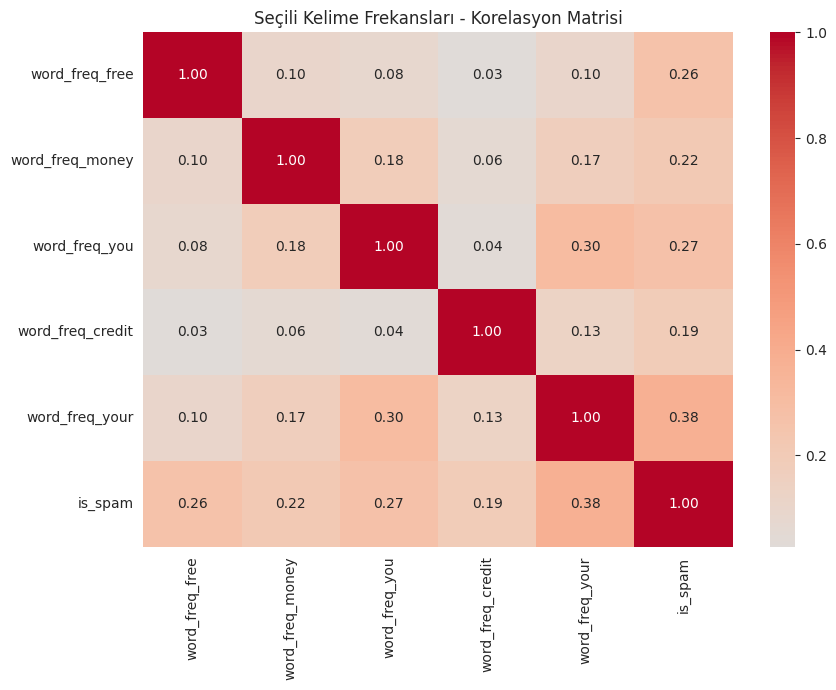

In [8]:
top_words = ['word_freq_free', 'word_freq_money', 'word_freq_you', 'word_freq_credit',
             'word_freq_your', 'is_spam']
plt.figure(figsize=(9, 7))
sns.heatmap(df[top_words].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Seçili Kelime Frekansları - Korelasyon Matrisi')
plt.tight_layout()
plt.show()

## 4️⃣ Veri Ön İşleme

In [9]:
X = df.drop(columns=['is_spam'])
y = df['is_spam']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Eğitim seti: {X_train.shape}, Test seti: {X_test.shape}")

Eğitim seti: (3680, 57), Test seti: (921, 57)


## 5️⃣ AdaBoost Sınıflandırma – Spam Tahmini

In [10]:
base_stump = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)

ada_clf = AdaBoostClassifier(
    estimator=base_stump,
    n_estimators=150,
    learning_rate=1.0,
    random_state=RANDOM_STATE
)
ada_clf.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",150
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


In [11]:
y_pred = ada_clf.predict(X_test)
y_proba = ada_clf.predict_proba(X_test)[:, 1]

print(f"Doğruluk (Accuracy) : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision            : {precision_score(y_test, y_pred):.4f}")
print(f"Recall               : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score             : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC              : {roc_auc_score(y_test, y_proba):.4f}")

Doğruluk (Accuracy) : 0.9305
Precision            : 0.9259
Recall               : 0.8953
F1-Score             : 0.9104
ROC-AUC              : 0.9789


In [12]:
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

              precision    recall  f1-score   support

         Ham       0.93      0.95      0.94       558
        Spam       0.93      0.90      0.91       363

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.93       921
weighted avg       0.93      0.93      0.93       921



/usr/local/lib/python3.12/dist-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


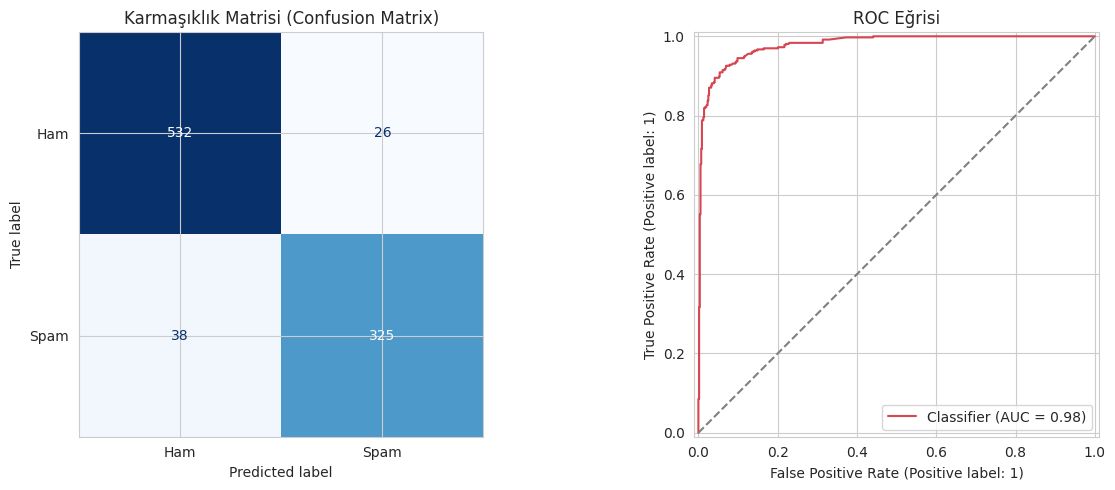

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Ham', 'Spam']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Karmaşıklık Matrisi (Confusion Matrix)')

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color='#D64550')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_title('ROC Eğrisi')
plt.tight_layout()
plt.show()

## 6️⃣ `n_estimators` (Kütük Sayısı) Etkisi

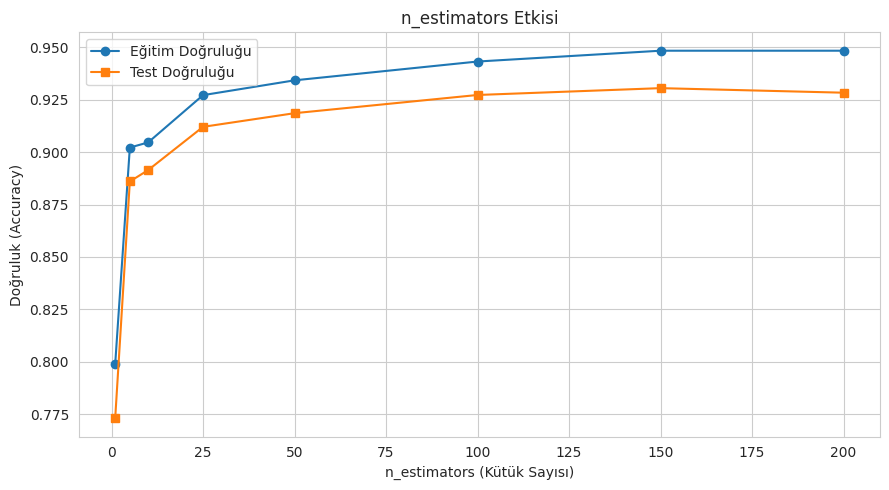

In [14]:
n_estimators_list = [1, 5, 10, 25, 50, 100, 150, 200]
train_scores, test_scores = [], []

for n in n_estimators_list:
    model = AdaBoostClassifier(estimator=base_stump, n_estimators=n, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(n_estimators_list, train_scores, marker='o', label='Eğitim Doğruluğu')
plt.plot(n_estimators_list, test_scores, marker='s', label='Test Doğruluğu')
plt.xlabel('n_estimators (Kütük Sayısı)')
plt.ylabel('Doğruluk (Accuracy)')
plt.title('n_estimators Etkisi')
plt.legend()
plt.tight_layout()
plt.show()

## 7️⃣ Özellik Önemi (Feature Importance)

/tmp/ipykernel_643/1755337680.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_imp, palette='viridis')


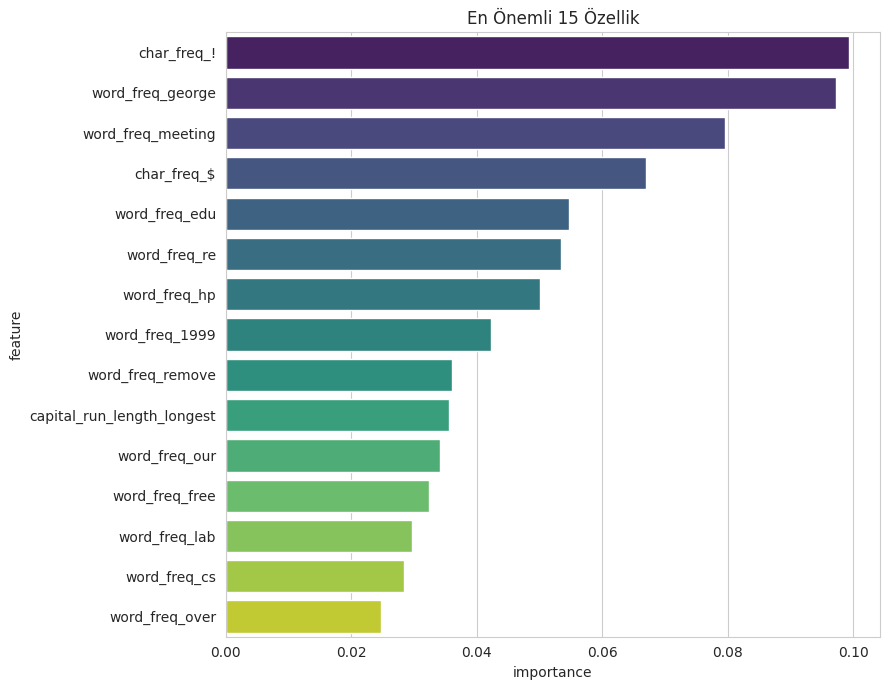

In [15]:
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': ada_clf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x='importance', y='feature', data=feat_imp, palette='viridis')
plt.title('En Önemli 15 Özellik')
plt.tight_layout()
plt.show()

## 8️⃣ Hiperparametre Optimizasyonu (Grid Search CV)

In [16]:
param_grid = {
    'n_estimators': [100, 150],
    'learning_rate': [0.5, 1.0]
}

grid_search = GridSearchCV(
    AdaBoostClassifier(estimator=base_stump, random_state=RANDOM_STATE),
    param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f"En iyi parametreler: {grid_search.best_params_}")
print(f"En iyi CV ROC-AUC   : {grid_search.best_score_:.4f}")

En iyi parametreler: {'learning_rate': 1.0, 'n_estimators': 150}
En iyi CV ROC-AUC   : 0.9809


In [17]:
best_ada = grid_search.best_estimator_
y_pred_best = best_ada.predict(X_test)
y_proba_best = best_ada.predict_proba(X_test)[:, 1]

print(f"Optimize Model ROC-AUC : {roc_auc_score(y_test, y_proba_best):.4f}")
print(f"Optimize Model F1      : {f1_score(y_test, y_pred_best):.4f}")

Optimize Model ROC-AUC : 0.9789
Optimize Model F1      : 0.9104


## 9️⃣ Çapraz Doğrulama (5-Fold Cross Validation)

In [18]:
cv_scores = cross_val_score(best_ada, X, y, cv=5, scoring='roc_auc')
print(f"5-Fold CV ROC-AUC skorları: {np.round(cv_scores, 4)}")
print(f"Ortalama: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")

5-Fold CV ROC-AUC skorları: [0.9805 0.9847 0.9843 0.9947 0.9024]
Ortalama: 0.9693  |  Std: 0.0338


## 🔟 Sonuç ve Değerlendirme

### 📈 AdaBoost Sınıflandırma Modeli — Spam E-posta Tespiti

- Zayıf öğrenici olarak **karar kütükleri (decision stump, max_depth=1)** kullanılmış, ardışık olarak eğitilen kütükler ağırlıklı oy ile birleştirilmiştir.
- `n_estimators` arttıkça test doğruluğu belirli bir seviyeye kadar yükselmekte, ardından platoya ulaşmaktadır — AdaBoost'un aşırı öğrenmeye (overfitting) diğer boosting yöntemlerine göre nispeten daha dirençli olduğu gözlemlenmiştir.
- `char_freq_!`, `char_freq_$` ve `word_freq_free` gibi değişkenler spam tespitinde en belirleyici öznitelikler arasındadır.
- Grid Search ile bulunan en iyi parametrelerle model, hem yüksek Recall hem de yüksek Precision değerleri üretmiştir.
- **Geliştirme Önerileri:** Daha derin zayıf öğreniciler (`max_depth=2,3`), SAMME.R yerine farklı algoritma varyantları veya metin tabanlı ek öznitelikler (n-gram, TF-IDF) ile performans artırılabilir.